##**Step 4: Model Implementation and Comparison**

This section develops, tunes, evaluates, and compares multiple supervised machine learning models for detecting fraudulent bank account applications. The objective is to identify a model that performs well on the minority fraud class, supports the bank's limited manual-review capacity, generalizes to future periods, and remains robust when applied to Variant II.

Base.csv will remain the primary dataset for model development. Earlier months will be used for training, month 6 for model and threshold selection, and month 7 for final testing. Variant II will not be merged with Base. Its month 7 records will be used as an external robustness stress test after the model and decision threshold have been finalized.

The model selected at the end of this section will be considered the provisional technical champion. The final recommendation will still depend on the explainability and fairness assessment in Step 5.

**a. Model Selection Strategy**

The project is a supervised binary classification problem with a known target variable, fraud_bool. Therefore, supervised classification models are more appropriate than clustering, recommendation, or unsupervised anomaly-detection methods for the primary solution.

The following models will be evaluated:

1. Dummy Classifier – establishes a no-skill baseline.

2. Logistic Regression – provides an interpretable linear benchmark.

3. Decision Tree – captures non-linear decision rules and remains relatively explainable.

4. Random Forest – captures complex feature interactions and reduces the instability of a single decision tree.

5. XGBoost – provides a strong gradient-boosting benchmark for structured tabular data.

A kernel-based SVM will not be used as a primary candidate because the dataset contains approximately one million records and becomes high-dimensional after categorical encoding. Kernel SVM training would be computationally expensive and difficult to scale. Deep learning will also not be prioritized because the data is structured tabular data, and strong tree-based models are generally more practical, explainable, and resource-efficient for this proof of concept.

The comparison will prioritize PR-AUC / Average Precision, followed by recall at the top 10% review rate, ROC-AUC, recall, precision, F1-score, false positive rate, false negative rate, and estimated business value.

**b. Modeling Configuration and Reproducibility**

The modeling configuration is defined in one location so that the experiments can be rerun consistently. The review rate and financial assumptions are scenario parameters and should be replaced with validated institutional values if such information becomes available.

In [ ]:
# Modeling configuration

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd

SEED = 42
TARGET_COL = "fraud_bool"
TIME_COL = "month"

# Operational policy
TOP_REVIEW_RATE = 0.10

# Resource-aware tuning configuration
TUNING_SAMPLE_SIZE = 150_000
N_ITER_SEARCH = 8
SEARCH_N_JOBS = 1

# Illustrative business assumptions only.
# Replace with validated institutional values when available.
BUSINESS_ASSUMPTIONS = {
    "estimated_loss_per_fraud": 10_000.0,
    "manual_review_cost": 100.0,
    "false_positive_cost": 250.0
}

MODEL_DIR = Path("models")
REPORT_DIR = Path("reports")
CONFIG_DIR = Path("configs")

for directory in [MODEL_DIR, REPORT_DIR, CONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

modeling_config = {
    "random_seed": SEED,
    "target_column": TARGET_COL,
    "time_column": TIME_COL,
    "primary_dataset": "Base.csv",
    "robustness_dataset": "Variant II.csv",
    "training_months": [0, 1, 2, 3, 4, 5],
    "validation_months": [6],
    "test_months": [7],
    "review_rate": TOP_REVIEW_RATE,
    "primary_metric": "PR-AUC / Average Precision",
    "tuning_sample_size": TUNING_SAMPLE_SIZE,
    "business_assumptions": BUSINESS_ASSUMPTIONS
}

display(pd.DataFrame(
    modeling_config.items(),
    columns=["configuration", "value"]
))

,configuration,value
0,random_seed,42
1,target_column,fraud_bool
2,time_column,month
3,primary_dataset,Base.csv
4,robustness_dataset,Variant II.csv
5,training_months,"[0, 1, 2, 3, 4, 5]"
6,validation_months,[6]
7,test_months,[7]
8,review_rate,0.1
9,primary_metric,PR-AUC / Average Precision


**c. Prepare the Modeling Datasets**

The feature-engineered datasets created in Step 3 will be used. The month variable will define the temporal split but will not be included as a predictor. Excluding it reduces the risk that the model simply learns an artificial month index rather than transferable fraud patterns.

The final test set must not be used for model selection, hyperparameter tuning, or threshold selection. It will be evaluated only after the model and operating threshold have been finalized using the training and validation data.

In [ ]:
# Prepare temporal modeling datasets

# These objects should already exist from Step 3:
# base_fe
# variant_ii_fe

required_objects = ["base_fe", "variant_ii_fe"]

for object_name in required_objects:
    if object_name not in globals():
        raise NameError(
            f"{object_name} is not available. Run Step 3 before Step 4."
        )

train_mask = base_fe[TIME_COL].isin([0, 1, 2, 3, 4, 5])
valid_mask = base_fe[TIME_COL].isin([6])
test_mask = base_fe[TIME_COL].isin([7])

MODEL_EXCLUDE_COLS = [TARGET_COL, TIME_COL]

X_train_full = base_fe.loc[train_mask].drop(
    columns=MODEL_EXCLUDE_COLS,
    errors="ignore"
).reset_index(drop=True)

y_train_full = base_fe.loc[
    train_mask, TARGET_COL
].reset_index(drop=True)

X_valid = base_fe.loc[valid_mask].drop(
    columns=MODEL_EXCLUDE_COLS,
    errors="ignore"
).reset_index(drop=True)

y_valid = base_fe.loc[
    valid_mask, TARGET_COL
].reset_index(drop=True)

X_test = base_fe.loc[test_mask].drop(
    columns=MODEL_EXCLUDE_COLS,
    errors="ignore"
).reset_index(drop=True)

y_test = base_fe.loc[
    test_mask, TARGET_COL
].reset_index(drop=True)

# Variant II month 7 is used as an external robustness test.
variant_test_mask = variant_ii_fe[TIME_COL].isin([7])

X_variant_test = variant_ii_fe.loc[variant_test_mask].drop(
    columns=MODEL_EXCLUDE_COLS,
    errors="ignore"
).reset_index(drop=True)

y_variant_test = variant_ii_fe.loc[
    variant_test_mask, TARGET_COL
].reset_index(drop=True)

split_summary = pd.DataFrame({
    "dataset": [
        "Base training",
        "Base validation",
        "Base final test",
        "Variant II robustness test"
    ],
    "rows": [
        len(X_train_full),
        len(X_valid),
        len(X_test),
        len(X_variant_test)
    ],
    "fraud_count": [
        int(y_train_full.sum()),
        int(y_valid.sum()),
        int(y_test.sum()),
        int(y_variant_test.sum())
    ],
    "fraud_rate_percent": [
        round(y_train_full.mean() * 100, 4),
        round(y_valid.mean() * 100, 4),
        round(y_test.mean() * 100, 4),
        round(y_variant_test.mean() * 100, 4)
    ]
})

display(split_summary)

,dataset,rows,fraud_count,fraud_rate_percent
0,Base training,794989,8151,1.0253
1,Base validation,108168,1450,1.3405
2,Base final test,96843,1428,1.4746
3,Variant II robustness test,96842,1428,1.4746


**d. Create a Resource-Aware Development Sample**

Hyperparameter tuning on the entire training dataset for every model may require substantial computing resources. To make experimentation practical and reproducible, the candidate models will be tuned on the same stratified development sample.

After the best configuration is identified, the winning model will be refitted using the complete Base training set. This preserves fair model comparison while allowing the final champion to use all available historical training data.

In [ ]:
# Create a stratified development sample

from sklearn.model_selection import train_test_split

def create_stratified_sample(X, y, sample_size, random_state=42):
    """
    Returns a stratified sample while preserving the fraud rate.
    """

    if len(X) <= sample_size:
        return X.copy(), y.copy()

    _, X_sample, _, y_sample = train_test_split(
        X,
        y,
        test_size=sample_size,
        stratify=y,
        random_state=random_state
    )

    return (
        X_sample.reset_index(drop=True),
        y_sample.reset_index(drop=True)
    )


X_dev, y_dev = create_stratified_sample(
    X_train_full,
    y_train_full,
    sample_size=TUNING_SAMPLE_SIZE,
    random_state=SEED
)

print("Development sample shape:", X_dev.shape)
print(
    "Development sample fraud rate:",
    round(y_dev.mean() * 100, 4),
    "%"
)

Development sample shape: (150000, 51)
Development sample fraud rate: 1.0253 %


**e. Build a Leakage-Safe Preprocessing Pipeline**

The preprocessing pipeline must be fitted only on the training portion inside each cross-validation fold. This prevents information from validation or test records from influencing imputation, scaling, or categorical encoding.

Numerical variables will be median-imputed and robustly scaled. Categorical variables will be imputed using the most frequent value and one-hot encoded. Sparse encoding is retained to reduce memory usage.

In [ ]:
# Leakage-safe preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

numeric_features = X_dev.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_dev.select_dtypes(
    exclude=np.number
).columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    # Compatibility with older scikit-learn versions
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder)
])

preprocessor_step4 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 43
Categorical features: 8


**f. Define the Evaluation Functions**

The evaluation functions calculate technical metrics, top-K operational metrics, and illustrative business KPIs. The decision threshold will be selected using the validation set rather than assuming that 0.50 is appropriate.

In [ ]:
# Technical and business evaluation functions

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

def evaluate_binary_classifier(y_true, y_score, threshold):
    """
    Computes threshold-based and ranking-based classification metrics.
    """

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1_score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "brier_score": brier_score_loss(y_true, y_score),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "true_negatives": int(tn),
        "false_negatives": int(fn),
        "false_positive_rate": (
            fp / (fp + tn) if (fp + tn) > 0 else 0
        ),
        "false_negative_rate": (
            fn / (fn + tp) if (fn + tp) > 0 else 0
        ),
        "predicted_positive_rate": float(y_pred.mean())
    }


def threshold_for_review_rate(y_score, review_rate=0.10):
    """
    Selects the probability threshold corresponding approximately
    to the top review_rate proportion of scores.
    """

    y_score = np.asarray(y_score)

    if not 0 < review_rate < 1:
        raise ValueError("review_rate must be between 0 and 1.")

    return float(np.quantile(y_score, 1 - review_rate))


def evaluate_top_k(y_true, y_score, review_rate=0.10):
    """
    Evaluates fraud capture within the top-K highest-risk records.
    """

    ranking = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(y_score)
    }).sort_values("score", ascending=False)

    review_count = int(np.ceil(len(ranking) * review_rate))
    reviewed = ranking.head(review_count)

    total_fraud = int(ranking["actual"].sum())
    fraud_captured = int(reviewed["actual"].sum())

    recall_at_k = (
        fraud_captured / total_fraud
        if total_fraud > 0 else 0
    )

    precision_at_k = (
        fraud_captured / review_count
        if review_count > 0 else 0
    )

    uplift = (
        precision_at_k / ranking["actual"].mean()
        if ranking["actual"].mean() > 0 else 0
    )

    return {
        "review_rate": review_rate,
        "applications_reviewed": review_count,
        "fraud_captured": fraud_captured,
        "total_fraud": total_fraud,
        "recall_at_k": recall_at_k,
        "precision_at_k": precision_at_k,
        "lift_at_k": uplift
    }


def evaluate_business_kpis(
    y_true,
    y_score,
    review_rate=0.10,
    estimated_loss_per_fraud=10_000,
    manual_review_cost=100,
    false_positive_cost=250
):
    """
    Estimates operational and financial KPIs using illustrative
    scenario assumptions.
    """

    ranking = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(y_score)
    }).sort_values("score", ascending=False)

    review_count = int(np.ceil(len(ranking) * review_rate))
    reviewed = ranking.head(review_count)

    fraud_captured = int(reviewed["actual"].sum())
    legitimate_flagged = int(
        review_count - fraud_captured
    )

    estimated_fraud_loss_avoided = (
        fraud_captured * estimated_loss_per_fraud
    )

    total_review_cost = (
        review_count * manual_review_cost
    )

    total_false_positive_cost = (
        legitimate_flagged * false_positive_cost
    )

    estimated_net_benefit = (
        estimated_fraud_loss_avoided
        - total_review_cost
        - total_false_positive_cost
    )

    return {
        "applications_reviewed": review_count,
        "fraud_captured": fraud_captured,
        "legitimate_applications_flagged": legitimate_flagged,
        "manual_review_efficiency": (
            fraud_captured / review_count
            if review_count > 0 else 0
        ),
        "estimated_fraud_loss_avoided":
            estimated_fraud_loss_avoided,
        "estimated_manual_review_cost":
            total_review_cost,
        "estimated_false_positive_cost":
            total_false_positive_cost,
        "estimated_net_benefit":
            estimated_net_benefit
    }

**g. Establish the No-Skill Baseline**

A baseline is necessary to show whether the machine learning models provide meaningful improvement. The Dummy Classifier predicts based on the observed class prior and provides a minimum performance reference.

In [ ]:
# Dummy baseline

from sklearn.dummy import DummyClassifier
from sklearn.base import clone

dummy_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_step4)),
    ("model", DummyClassifier(
        strategy="prior",
        random_state=SEED
    ))
])

dummy_pipeline.fit(X_dev, y_dev)

dummy_valid_score = dummy_pipeline.predict_proba(
    X_valid
)[:, 1]

dummy_threshold = threshold_for_review_rate(
    dummy_valid_score,
    TOP_REVIEW_RATE
)

dummy_metrics = evaluate_binary_classifier(
    y_valid,
    dummy_valid_score,
    dummy_threshold
)

dummy_top_k = evaluate_top_k(
    y_valid,
    dummy_valid_score,
    TOP_REVIEW_RATE
)

display(pd.DataFrame([{
    "model": "Dummy Classifier",
    **dummy_metrics,
    **dummy_top_k
}]))

,model,threshold,accuracy,pr_auc,roc_auc,precision,recall,f1_score,brier_score,true_positives,...,false_positive_rate,false_negative_rate,predicted_positive_rate,review_rate,applications_reviewed,fraud_captured,total_fraud,recall_at_k,precision_at_k,lift_at_k
0,Dummy Classifier,0.010253,0.013405,0.013405,0.5,0.013405,1.0,0.026456,0.013235,1450,...,1.0,0.0,1.0,0.1,10817,152,1450,0.104828,0.014052,1.048256


**h. Define Candidate Models and Hyperparameter Spaces**

The model set provides a progression from an interpretable linear benchmark to more flexible non-linear ensemble approaches. Logistic Regression serves as the transparent baseline. Decision Tree captures non-linear rules but may be unstable when used alone. Random Forest reduces this instability through ensemble learning, while XGBoost provides a strong gradient-boosting approach for structured tabular data.

Logistic Regression uses the newton-cg solver instead of the first configuration tested, which reached its maximum iteration limit. The regularization search remains centered around the previously promising range. Class weighting is applied to Logistic Regression, Decision Tree, and Random Forest, while XGBoost uses scale_pos_weight calculated from the development data.

In [ ]:
# Define candidate models and hyperparameter spaces

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import numpy as np


# Confirm that required development data exists
required_objects = [
    "X_dev",
    "y_dev",
    "preprocessor_step4",
    "SEED"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_objects)
    )


# Tuning configuration
N_ITER_SEARCH = 8

# Keep the outer search single-threaded for Colab stability.
# Random Forest and XGBoost can still use their own internal parallelism.
SEARCH_N_JOBS = 1


# Calculate class imbalance ratio for XGBoost
negative_count = int((y_dev == 0).sum())
positive_count = int((y_dev == 1).sum())

scale_pos_weight = (
    negative_count / positive_count
    if positive_count > 0
    else 1.0
)


candidate_models = {

    "Logistic Regression": {
        "estimator": LogisticRegression(
            solver="newton-cg",
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            tol=1e-4,
            random_state=SEED
        ),
        "parameters": {
            "model__C": [
                0.02,
                0.05,
                0.10,
                0.25,
                0.50
            ]
        }
    },

    "Decision Tree": {
        "estimator": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=SEED
        ),
        "parameters": {
            "model__max_depth": [
                4,
                6,
                8,
                12,
                None
            ],
            "model__min_samples_leaf": [
                20,
                50,
                100,
                250
            ],
            "model__max_features": [
                None,
                "sqrt",
                "log2"
            ]
        }
    },

    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        ),
        "parameters": {
            "model__n_estimators": [
                200,
                300,
                500
            ],
            "model__max_depth": [
                8,
                12,
                16,
                None
            ],
            "model__min_samples_leaf": [
                5,
                10,
                25,
                50
            ],
            "model__max_features": [
                "sqrt",
                "log2",
                0.50
            ]
        }
    },

    "XGBoost": {
        "estimator": XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            n_jobs=-1
        ),
        "parameters": {
            "model__n_estimators": [
                200,
                400,
                600
            ],
            "model__max_depth": [
                3,
                5,
                7
            ],
            "model__learning_rate": [
                0.03,
                0.05,
                0.10
            ],
            "model__subsample": [
                0.70,
                0.85,
                1.00
            ],
            "model__colsample_bytree": [
                0.70,
                0.85,
                1.00
            ],
            "model__min_child_weight": [
                1,
                5,
                10
            ],
            "model__reg_lambda": [
                1.0,
                5.0,
                10.0
            ]
        }
    }
}


print("Candidate models:")

for model_name in candidate_models:
    print("-", model_name)

print("\nDevelopment sample records:", len(X_dev))
print("Fraud cases:", positive_count)
print("Legitimate cases:", negative_count)
print("Fraud rate:", round(y_dev.mean() * 100, 4), "%")
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 2))

Candidate models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Development sample records: 150000
Fraud cases: 1538
Legitimate cases: 148462
Fraud rate: 1.0253 %
XGBoost scale_pos_weight: 96.53


**i. Hyperparameter Tuning**

The tuning procedure uses PR-AUC or Average Precision as the scoring metric because fraud is the rare positive class. The method first counts the complete parameter search space. Small spaces are evaluated through GridSearchCV, while larger spaces use RandomizedSearchCV with the configured tuning budget.

A stratified three-fold cross-validation strategy preserves the fraud proportion in each fold. The code records convergence warnings, number of candidates, number of model fits, best parameters, best cross-validated PR-AUC, and execution time.

For the Logistic Regression, the maximum iteration limit was reached on the first run. Hence, the script below is the revision and if it still reaches the maximum iteration limit, the code automatically repeats its search with max_iter=3000. The ensemble models are unaffected by this retry.

In [ ]:
# Hyperparameter tuning with automatic convergence handling

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    ParameterGrid
)
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.exceptions import ConvergenceWarning

import warnings
import time
import numpy as np
import pandas as pd

# Reproducible stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)


tuned_models = {}
search_objects = {}
tuning_summaries = []

# Ensure the report folder exists
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

def inspect_convergence(fitted_pipeline):
    """
    Inspect whether the fitted estimator reached its configured
    maximum number of iterations.

    Returns:
        maximum_iterations_used
        configured_max_iter
        convergence_status
    """

    fitted_estimator = (
        fitted_pipeline
        .named_steps["model"]
    )

    model_n_iter = getattr(
        fitted_estimator,
        "n_iter_",
        None
    )

    model_max_iter = (
        fitted_estimator
        .get_params()
        .get("max_iter", None)
    )

    maximum_iterations_used = None
    convergence_status = "Not applicable"

    if model_n_iter is not None:

        maximum_iterations_used = int(
            np.max(model_n_iter)
        )

        if (
            model_max_iter is not None
            and maximum_iterations_used >= model_max_iter
        ):
            convergence_status = (
                "Maximum iterations reached"
            )
        else:
            convergence_status = "Converged"

    return (
        maximum_iterations_used,
        model_max_iter,
        convergence_status
    )

def build_search(
    pipeline,
    parameter_space
):
    """
    Select GridSearchCV for a small complete search space and
    RandomizedSearchCV for a larger search space.
    """

    total_candidates = len(
        ParameterGrid(parameter_space)
    )

    common_arguments = {
        "estimator": pipeline,
        "scoring": "average_precision",
        "cv": cv_strategy,
        "n_jobs": SEARCH_N_JOBS,
        "verbose": 1,
        "refit": True,
        "return_train_score": True,
        "error_score": "raise",
        "pre_dispatch": 1
    }

    if total_candidates <= N_ITER_SEARCH:

        search_method = "GridSearchCV"
        candidates_evaluated = total_candidates

        search = GridSearchCV(
            param_grid=parameter_space,
            **common_arguments
        )

    else:

        search_method = "RandomizedSearchCV"

        candidates_evaluated = min(
            N_ITER_SEARCH,
            total_candidates
        )

        search = RandomizedSearchCV(
            param_distributions=parameter_space,
            n_iter=candidates_evaluated,
            random_state=SEED,
            **common_arguments
        )

    return (
        search,
        search_method,
        total_candidates,
        candidates_evaluated
    )

for model_name, specification in candidate_models.items():

    print("\n" + "=" * 90)
    print(f"Tuning: {model_name}")

    start_time = time.time()

    model_pipeline = Pipeline(steps=[
        (
            "preprocessor",
            clone(preprocessor_step4)
        ),
        (
            "model",
            clone(specification["estimator"])
        )
    ])

    parameter_space = (
        specification["parameters"]
    )

    (
        search,
        search_method,
        total_candidates,
        candidates_evaluated
    ) = build_search(
        model_pipeline,
        parameter_space
    )

    expected_fits = (
        candidates_evaluated
        * cv_strategy.get_n_splits()
    )

    print(
        "Available parameter combinations:",
        total_candidates
    )

    print(
        "Search method:",
        search_method
    )

    print(
        "Candidates evaluated:",
        candidates_evaluated
    )

    print(
        "Expected cross-validation fits:",
        expected_fits
    )

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter(
            "always",
            category=ConvergenceWarning
        )

        search.fit(
            X_dev,
            y_dev
        )

    convergence_warnings = [
        warning
        for warning in captured_warnings
        if issubclass(
            warning.category,
            ConvergenceWarning
        )
    ]

    best_pipeline = search.best_estimator_

    (
        maximum_iterations_used,
        configured_max_iter,
        convergence_status
    ) = inspect_convergence(
        best_pipeline
    )

    retry_performed = False

    # Automatically retry only Logistic Regression when necessary
    if (
        model_name == "Logistic Regression"
        and (
            convergence_status
            == "Maximum iterations reached"
            or len(convergence_warnings) > 0
        )
    ):

        retry_performed = True

        print(
            "\nLogistic Regression did not converge."
        )

        print(
            "Automatically retrying with max_iter=3000."
        )

        retry_estimator = clone(
            specification["estimator"]
        )

        retry_estimator.set_params(
            max_iter=3000
        )

        retry_pipeline = Pipeline(steps=[
            (
                "preprocessor",
                clone(preprocessor_step4)
            ),
            (
                "model",
                retry_estimator
            )
        ])

        (
            retry_search,
            retry_search_method,
            retry_total_candidates,
            retry_candidates_evaluated
        ) = build_search(
            retry_pipeline,
            parameter_space
        )

        with warnings.catch_warnings(
            record=True
        ) as retry_captured_warnings:

            warnings.simplefilter(
                "always",
                category=ConvergenceWarning
            )

            retry_search.fit(
                X_dev,
                y_dev
            )

        retry_convergence_warnings = [
            warning
            for warning
            in retry_captured_warnings
            if issubclass(
                warning.category,
                ConvergenceWarning
            )
        ]

        retry_best_pipeline = (
            retry_search.best_estimator_
        )

        (
            retry_maximum_iterations_used,
            retry_configured_max_iter,
            retry_convergence_status
        ) = inspect_convergence(
            retry_best_pipeline
        )

        # Use the retry result when it converged.
        # If both converged, retain the better CV result.
        use_retry_result = (
            retry_convergence_status
            == "Converged"
        )

        if (
            convergence_status == "Converged"
            and retry_search.best_score_
            <= search.best_score_
        ):
            use_retry_result = False

        if use_retry_result:

            search = retry_search
            search_method = (
                retry_search_method
                + " with convergence retry"
            )

            total_candidates = (
                retry_total_candidates
            )

            candidates_evaluated = (
                retry_candidates_evaluated
            )

            expected_fits = (
                candidates_evaluated
                * cv_strategy.get_n_splits()
            )

            convergence_warnings = (
                retry_convergence_warnings
            )

            best_pipeline = (
                retry_best_pipeline
            )

            maximum_iterations_used = (
                retry_maximum_iterations_used
            )

            configured_max_iter = (
                retry_configured_max_iter
            )

            convergence_status = (
                retry_convergence_status
            )

    elapsed_seconds = (
        time.time() - start_time
    )

    tuned_models[
        model_name
    ] = best_pipeline

    search_objects[
        model_name
    ] = search

    tuning_summaries.append({
        "model": model_name,
        "search_method": search_method,
        "total_parameter_combinations":
            total_candidates,
        "candidates_evaluated":
            candidates_evaluated,
        "cv_folds":
            cv_strategy.get_n_splits(),
        "total_model_fits":
            expected_fits,
        "best_cv_pr_auc":
            search.best_score_,
        "best_parameters":
            search.best_params_,
        "retry_performed":
            retry_performed,
        "convergence_warning_count":
            len(convergence_warnings),
        "maximum_iterations_used":
            maximum_iterations_used,
        "configured_max_iter":
            configured_max_iter,
        "convergence_status":
            convergence_status,
        "tuning_seconds":
            elapsed_seconds
    })

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    pd.DataFrame(
        search.cv_results_
    ).to_csv(
        REPORT_DIR
        / f"step4_cv_results_{safe_model_name}.csv",
        index=False
    )

    print(
        f"\nBest CV PR-AUC: "
        f"{search.best_score_:.6f}"
    )

    print(
        "Best parameters:",
        search.best_params_
    )

    print(
        "Convergence status:",
        convergence_status
    )

    print(
        "Convergence warnings:",
        len(convergence_warnings)
    )

    print(
        "Automatic retry performed:",
        retry_performed
    )

    print(
        f"Tuning time: "
        f"{elapsed_seconds:.2f} seconds"
    )


tuning_summary_df = (
    pd.DataFrame(tuning_summaries)
    .sort_values(
        "best_cv_pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tuning_summary_df)


Tuning: Logistic Regression
Available parameter combinations: 5
Search method: GridSearchCV
Candidates evaluated: 5
Expected cross-validation fits: 15
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best CV PR-AUC: 0.137709
Best parameters: {'model__C': 0.02}
Convergence status: Converged
Convergence warnings: 0
Automatic retry performed: False
Tuning time: 261.39 seconds

Tuning: Decision Tree
Available parameter combinations: 60
Search method: RandomizedSearchCV
Candidates evaluated: 8
Expected cross-validation fits: 24
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best CV PR-AUC: 0.057354
Best parameters: {'model__min_samples_leaf': 100, 'model__max_features': 'sqrt', 'model__max_depth': None}
Convergence status: Not applicable
Convergence warnings: 0
Automatic retry performed: False
Tuning time: 118.56 seconds

Tuning: Random Forest
Available parameter combinations: 144
Search method: RandomizedSearchCV
Candidates evaluated: 8
Expected cross-validation 

,model,search_method,total_parameter_combinations,candidates_evaluated,cv_folds,total_model_fits,best_cv_pr_auc,best_parameters,retry_performed,convergence_warning_count,maximum_iterations_used,configured_max_iter,convergence_status,tuning_seconds
0,XGBoost,RandomizedSearchCV,2187,8,3,24,0.140452,"{'model__subsample': 0.85, 'model__reg_lambda'...",False,0,NaN,NaN,Not applicable,465.070050
1,Logistic Regression,GridSearchCV,5,5,3,15,0.137709,{'model__C': 0.02},False,0,13.0,1000.0,Converged,261.390646
2,Random Forest,RandomizedSearchCV,144,8,3,24,0.122551,"{'model__n_estimators': 300, 'model__min_sampl...",False,0,NaN,NaN,Not applicable,5542.659637
3,Decision Tree,RandomizedSearchCV,60,8,3,24,0.057354,"{'model__min_samples_leaf': 100, 'model__max_f...",False,0,NaN,NaN,Not applicable,118.564712


**j. Validation-Set Model Comparison**

Hyperparameter tuning identifies configurations that perform well across the development folds, but the independent month 6 validation set provides stronger evidence of generalization. The validation set was not used in tuning.

Each model will be evaluated using PR-AUC, ROC-AUC, recall, precision, F1-score, false positive rate, false negative rate, Brier score, top-10% fraud capture, lift, investigation workload, and estimated business value.

The comparison uses the cross-validated PR-AUC from Step 4I as the development estimate instead of computing an optimistic in-sample training score.

In [ ]:
# Compare tuned models on the independent validation set

from sklearn.metrics import average_precision_score


all_models = {
    "Dummy Classifier": dummy_pipeline,
    **tuned_models
}


cv_pr_auc_lookup = (
    tuning_summary_df
    .set_index("model")[
        "best_cv_pr_auc"
    ]
    .to_dict()
)


validation_results = []
validation_scores = {}
validation_thresholds = {}


for model_name, model in all_models.items():

    valid_score = model.predict_proba(
        X_valid
    )[:, 1]

    threshold = threshold_for_review_rate(
        valid_score,
        TOP_REVIEW_RATE
    )

    technical_metrics = (
        evaluate_binary_classifier(
            y_valid,
            valid_score,
            threshold
        )
    )

    top_k_metrics = evaluate_top_k(
        y_valid,
        valid_score,
        TOP_REVIEW_RATE
    )

    business_metrics = (
        evaluate_business_kpis(
            y_valid,
            valid_score,
            review_rate=TOP_REVIEW_RATE,
            **BUSINESS_ASSUMPTIONS
        )
    )

    if model_name == "Dummy Classifier":

        development_cv_pr_auc = (
            average_precision_score(
                y_dev,
                model.predict_proba(
                    X_dev
                )[:, 1]
            )
        )

        search_method = (
            "No-skill baseline"
        )

        convergence_status = (
            "Not applicable"
        )

    else:

        development_cv_pr_auc = (
            cv_pr_auc_lookup[
                model_name
            ]
        )

        model_summary = (
            tuning_summary_df.loc[
                tuning_summary_df["model"]
                == model_name
            ]
            .iloc[0]
        )

        search_method = (
            model_summary[
                "search_method"
            ]
        )

        convergence_status = (
            model_summary[
                "convergence_status"
            ]
        )

    validation_scores[
        model_name
    ] = valid_score

    validation_thresholds[
        model_name
    ] = threshold

    validation_results.append({
        "model": model_name,
        "search_method":
            search_method,
        "convergence_status":
            convergence_status,
        "development_cv_pr_auc":
            development_cv_pr_auc,
        **technical_metrics,
        "generalization_gap_pr_auc": (
            development_cv_pr_auc
            - technical_metrics["pr_auc"]
        ),
        "pr_auc_lift_over_prevalence": (
            technical_metrics["pr_auc"]
            / y_valid.mean()
            if y_valid.mean() > 0
            else np.nan
        ),
        **top_k_metrics,
        **business_metrics
    })


validation_comparison = (
    pd.DataFrame(
        validation_results
    )
    .sort_values(
        by=[
            "pr_auc",
            "recall_at_k",
            "estimated_net_benefit"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


display(validation_comparison)

,model,search_method,convergence_status,development_cv_pr_auc,threshold,accuracy,pr_auc,roc_auc,precision,recall,...,total_fraud,recall_at_k,precision_at_k,lift_at_k,legitimate_applications_flagged,manual_review_efficiency,estimated_fraud_loss_avoided,estimated_manual_review_cost,estimated_false_positive_cost,estimated_net_benefit
0,Logistic Regression,GridSearchCV,Converged,0.137709,0.681254,0.903456,0.164799,0.882639,0.084312,0.628966,...,1450,0.628966,0.084312,6.289539,9905,0.084312,9120000.0,1081700.0,2476250.0,5562050.0
1,XGBoost,RandomizedSearchCV,Not applicable,0.140452,0.619034,0.903271,0.154837,0.881981,0.083387,0.622069,...,1450,0.622069,0.083387,6.220575,9915,0.083387,9020000.0,1081700.0,2478750.0,5459550.0
2,Random Forest,RandomizedSearchCV,Not applicable,0.122551,0.383999,0.903197,0.144616,0.871223,0.083017,0.619310,...,1450,0.619310,0.083017,6.192989,9919,0.083017,8980000.0,1081700.0,2479750.0,5418550.0
3,Decision Tree,RandomizedSearchCV,Not applicable,0.057354,0.799220,0.896069,0.063402,0.743139,0.057003,0.434483,...,1450,0.431724,0.057872,4.317162,10191,0.057872,6260000.0,1081700.0,2547750.0,2630550.0
4,Dummy Classifier,No-skill baseline,Not applicable,0.010253,0.010253,0.013405,0.013405,0.500000,0.013405,1.000000,...,1450,0.104828,0.014052,1.048256,10665,0.014052,1520000.0,1081700.0,2666250.0,-2227950.0


The primary validation metric remains PR-AUC. Recall at the top 10% indicates how much fraud is captured under the assumed review capacity, while precision at the top 10% indicates how productive the review queue would be. The generalization gap helps identify possible overfitting.

**k. Visual Model Comparison**

These plots communicate the relative performance of the candidate models. Separate charts are used because PR-AUC, operational fraud capture, precision-recall performance, and ROC discrimination answer different questions.

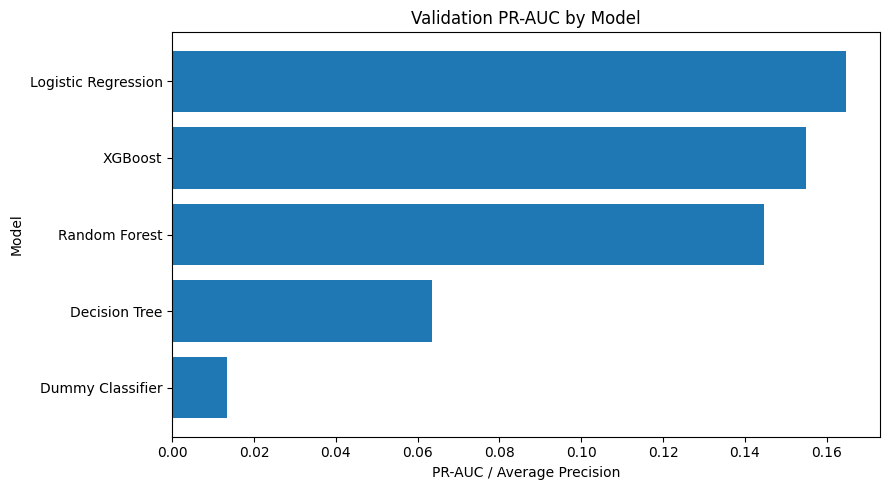

In [ ]:
# 1. Validation PR-AUC comparison

import matplotlib.pyplot as plt

plot_df = (
    validation_comparison
    .sort_values(
        "pr_auc",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["model"],
    plot_df["pr_auc"]
)

plt.title(
    "Validation PR-AUC by Model"
)

plt.xlabel(
    "PR-AUC / Average Precision"
)

plt.ylabel("Model")

plt.tight_layout()
plt.show()

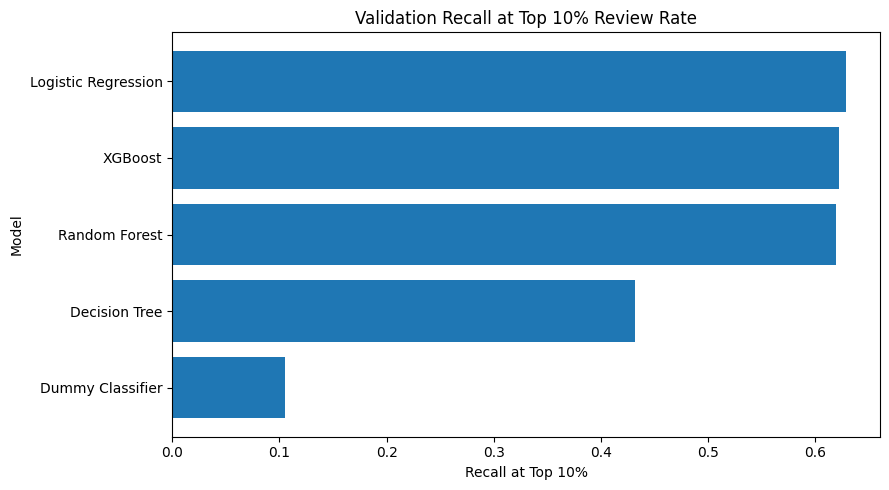

In [ ]:
# 2. Recall at top 10% review rate

plot_df = (
    validation_comparison
    .sort_values(
        "recall_at_k",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["model"],
    plot_df["recall_at_k"]
)

plt.title(
    "Validation Recall at Top 10% Review Rate"
)

plt.xlabel(
    "Recall at Top 10%"
)

plt.ylabel("Model")

plt.tight_layout()
plt.show()

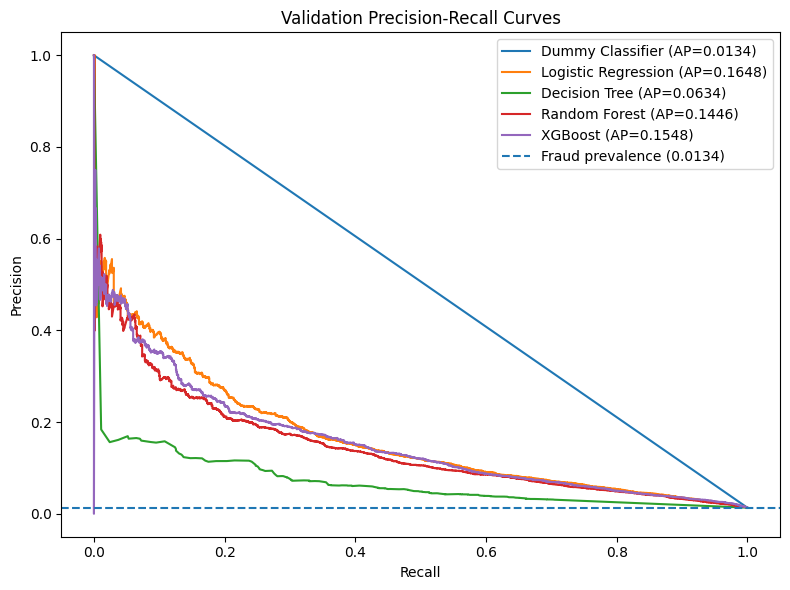

In [ ]:
# 3. Precision-recall curves

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(8, 6))

for (
    model_name,
    valid_score
) in validation_scores.items():

    (
        precision_values,
        recall_values,
        _
    ) = precision_recall_curve(
        y_valid,
        valid_score
    )

    model_ap = (
        average_precision_score(
            y_valid,
            valid_score
        )
    )

    plt.plot(
        recall_values,
        precision_values,
        label=(
            f"{model_name} "
            f"(AP={model_ap:.4f})"
        )
    )

fraud_prevalence = y_valid.mean()

plt.axhline(
    fraud_prevalence,
    linestyle="--",
    label=(
        "Fraud prevalence "
        f"({fraud_prevalence:.4f})"
    )
)

plt.title(
    "Validation Precision-Recall Curves"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

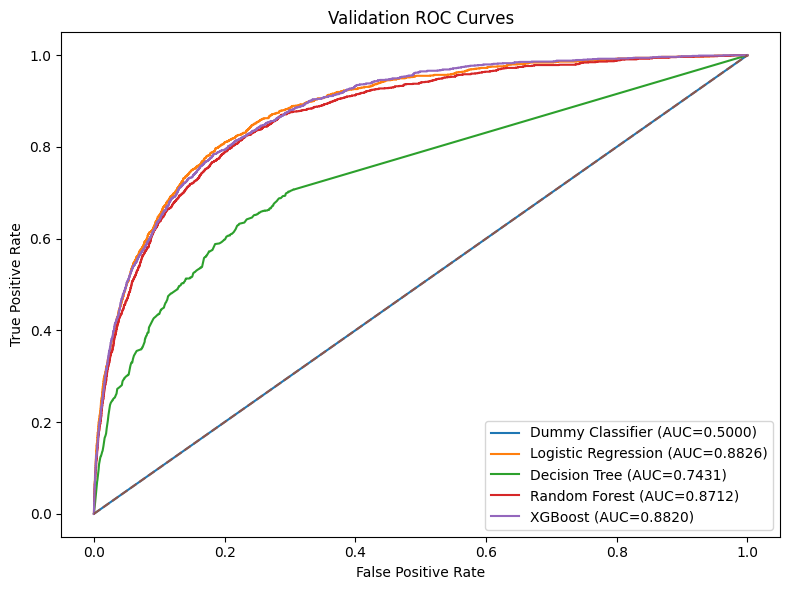

In [ ]:
# 4. ROC curves

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

plt.figure(figsize=(8, 6))

for (
    model_name,
    valid_score
) in validation_scores.items():

    (
        false_positive_rate,
        true_positive_rate,
        _
    ) = roc_curve(
        y_valid,
        valid_score
    )

    model_roc_auc = (
        roc_auc_score(
            y_valid,
            valid_score
        )
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{model_name} "
            f"(AUC={model_roc_auc:.4f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "Validation ROC Curves"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()
plt.tight_layout()
plt.show()

**l. Select the Provisional Technical Champion**

The champion is selected primarily by validation PR-AUC. Recall at the top 10% and estimated net benefit are supporting tie-breakers. A model that did not converge is excluded because its fitted parameters may not represent a stable optimization result.

This champion is still provisional. The next steps may identify explainability or fairness concerns that change the final operational recommendation.

In [ ]:
# l. Select the provisional technical champion

eligible_models = (
    validation_comparison.loc[
        validation_comparison["model"]
        != "Dummy Classifier"
    ]
    .copy()
)


eligible_models = (
    eligible_models.loc[
        eligible_models[
            "convergence_status"
        ].isin([
            "Converged",
            "Not applicable"
        ])
    ]
    .copy()
)


if eligible_models.empty:
    raise RuntimeError(
        "No eligible model remains after "
        "convergence screening."
    )


eligible_models = (
    eligible_models
    .sort_values(
        by=[
            "pr_auc",
            "recall_at_k",
            "estimated_net_benefit"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


champion_name = (
    eligible_models.iloc[0][
        "model"
    ]
)


champion_development_model = (
    tuned_models[
        champion_name
    ]
)


print(
    "Provisional technical champion:",
    champion_name
)


display(
    eligible_models
    .head(1)
    .T
    .rename(
        columns={
            0: "Champion Result"
        }
    )
)

Provisional technical champion: Logistic Regression


,Champion Result
model,Logistic Regression
search_method,GridSearchCV
convergence_status,Converged
development_cv_pr_auc,0.137709
threshold,0.681254
accuracy,0.903456
pr_auc,0.164799
roc_auc,0.882639
precision,0.084312
recall,0.628966


**m. Refit the Champion on the Complete Training Set**

The champion’s hyperparameters were identified using the development sample. The selected pipeline is now cloned and refitted using all Base training records from months 0 through 5.

Month 6 remains separate and is used to select the operating threshold. Month 7 remains untouched until final test evaluation.

In [ ]:
# Refit the champion on the complete Base training set

from sklearn.base import clone

champion_model = clone(
    champion_development_model
)

champion_model.fit(
    X_train_full,
    y_train_full
)

champion_valid_score = (
    champion_model
    .predict_proba(
        X_valid
    )[:, 1]
)

champion_threshold = (
    threshold_for_review_rate(
        champion_valid_score,
        TOP_REVIEW_RATE
    )
)

print(
    "Champion model:",
    champion_name
)

print(
    "Selected validation threshold:",
    champion_threshold
)

Champion model: Logistic Regression
Selected validation threshold: 0.658130128570441


The following diagnostic confirms whether an iterative champion converged when trained on the complete Base training set.

In [ ]:
# Full-training convergence diagnostic

final_estimator = (
    champion_model
    .named_steps["model"]
)
final_n_iter = getattr(
    final_estimator,
    "n_iter_",
    None
)
final_max_iter = (
    final_estimator
    .get_params()
    .get(
        "max_iter",
        None
    )
)
if final_n_iter is not None:

    final_iterations_used = int(
        np.max(
            final_n_iter
        )
    )
    print(
        "Maximum iterations used:",
        final_iterations_used
    )
    print(
        "Configured maximum iterations:",
        final_max_iter
    )
    if (
        final_max_iter is not None
        and final_iterations_used
        >= final_max_iter
    ):
        raise RuntimeError(
            "The final champion reached max_iter. "
            "Increase max_iter and refit it before "
            "final test evaluation."
        )
    print(
        "Full-training convergence "
        "diagnostic passed."
    )
else:
    print(
        "Iteration-based convergence "
        f"diagnostic is not applicable "
        f"to {champion_name}."
    )

Maximum iterations used: 8
Configured maximum iterations: 1000
Full-training convergence diagnostic passed.


**n. Final Evaluation on the Base Test Set**

The Base month 7 test set is evaluated only after model selection, full training, and threshold selection are complete. This provides the main held-out estimate of future-period performance.

In [ ]:
# Final evaluation on the Base month 7 test set

champion_test_score = (
    champion_model
    .predict_proba(
        X_test
    )[:, 1]
)
base_test_technical = (
    evaluate_binary_classifier(
        y_test,
        champion_test_score,
        champion_threshold
    )
)
base_test_top_k = (
    evaluate_top_k(
        y_test,
        champion_test_score,
        TOP_REVIEW_RATE
    )
)
base_test_business = (
    evaluate_business_kpis(
        y_test,
        champion_test_score,
        review_rate=TOP_REVIEW_RATE,
        **BUSINESS_ASSUMPTIONS
    )
)
base_test_results = pd.DataFrame([{
    "dataset":
        "Base month 7",
    "model":
        champion_name,
    **base_test_technical,
    **base_test_top_k,
    **base_test_business
}])
display(
    base_test_results.T
)

,0
dataset,Base month 7
model,Logistic Regression
threshold,0.65813
accuracy,0.922648
pr_auc,0.198539
roc_auc,0.890668
precision,0.114067
recall,0.627451
f1_score,0.193041
brier_score,0.102045


**o. Confusion Matrix and Error Interpretation**

The confusion matrix shows the operational consequences of the selected threshold. False negatives represent fraudulent applications missed by the model, while false positives represent legitimate applications unnecessarily routed for review.

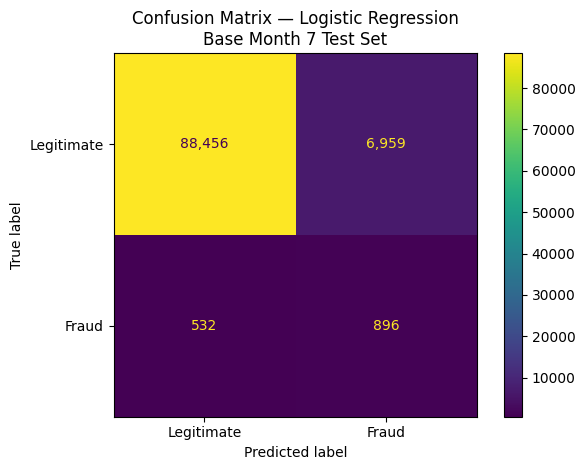

In [ ]:
# Confusion matrix for the champion model

from sklearn.metrics import (
    ConfusionMatrixDisplay
)
champion_test_prediction = (
    champion_test_score
    >= champion_threshold
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    champion_test_prediction,
    labels=[0, 1],
    display_labels=[
        "Legitimate",
        "Fraud"
    ],
    values_format=",d"
)

plt.title(
    f"Confusion Matrix — {champion_name}\n"
    "Base Month 7 Test Set"
)

plt.tight_layout()
plt.show()

**p. Variant II Robustness Stress Test**

The champion trained on Base is applied directly to Variant II month 7 without retraining. The same threshold selected from Base validation is retained. This tests whether the fraud patterns learned from Base remain useful under a different controlled data variant.

In [ ]:
# Variant II robustness stress test

variant_test_score = (
    champion_model
    .predict_proba(
        X_variant_test
    )[:, 1]
)

variant_test_technical = (
    evaluate_binary_classifier(
        y_variant_test,
        variant_test_score,
        champion_threshold
    )
)

variant_test_top_k = (
    evaluate_top_k(
        y_variant_test,
        variant_test_score,
        TOP_REVIEW_RATE
    )
)


variant_test_business = (
    evaluate_business_kpis(
        y_variant_test,
        variant_test_score,
        review_rate=TOP_REVIEW_RATE,
        **BUSINESS_ASSUMPTIONS
    )
)

variant_test_results = pd.DataFrame([{
    "dataset":
        "Variant II month 7",
    "model":
        champion_name,
    **variant_test_technical,
    **variant_test_top_k,
    **variant_test_business
}])


robustness_comparison = pd.concat(
    [
        base_test_results,
        variant_test_results
    ],
    ignore_index=True
)

display(
    robustness_comparison
)

,dataset,model,threshold,accuracy,pr_auc,roc_auc,precision,recall,f1_score,brier_score,...,total_fraud,recall_at_k,precision_at_k,lift_at_k,legitimate_applications_flagged,manual_review_efficiency,estimated_fraud_loss_avoided,estimated_manual_review_cost,estimated_false_positive_cost,estimated_net_benefit
0,Base month 7,Logistic Regression,0.65813,0.922648,0.198539,0.890668,0.114067,0.627451,0.193041,0.102045,...,1428,0.670168,0.098813,6.701196,8728,0.098813,9570000.0,968500.0,2182000.0,6419500.0
1,Variant II month 7,Logistic Regression,0.65813,0.876634,0.201282,0.889638,0.081483,0.717087,0.146338,0.144208,...,1428,0.664566,0.097987,6.645109,8736,0.097987,9490000.0,968500.0,2184000.0,6337500.0


In [ ]:
# Quantify the Base-to-Variant-II performance gap

base_row = (
    robustness_comparison.loc[
        robustness_comparison["dataset"]
        == "Base month 7"
    ]
    .iloc[0]
)

variant_row = (
    robustness_comparison.loc[
        robustness_comparison["dataset"]
        == "Variant II month 7"
    ]
    .iloc[0]
)

robustness_gap = pd.DataFrame({
    "metric": [
        "PR-AUC",
        "ROC-AUC",
        "Recall",
        "Precision",
        "F1-score",
        "False Positive Rate",
        "False Negative Rate",
        "Recall at Top 10%",
        "Precision at Top 10%",
        "Lift at Top 10%",
        "Estimated Net Benefit"
    ],

    "base_value": [
        base_row["pr_auc"],
        base_row["roc_auc"],
        base_row["recall"],
        base_row["precision"],
        base_row["f1_score"],
        base_row[
            "false_positive_rate"
        ],
        base_row[
            "false_negative_rate"
        ],
        base_row["recall_at_k"],
        base_row["precision_at_k"],
        base_row["lift_at_k"],
        base_row[
            "estimated_net_benefit"
        ]
    ],

    "variant_ii_value": [
        variant_row["pr_auc"],
        variant_row["roc_auc"],
        variant_row["recall"],
        variant_row["precision"],
        variant_row["f1_score"],
        variant_row[
            "false_positive_rate"
        ],
        variant_row[
            "false_negative_rate"
        ],
        variant_row["recall_at_k"],
        variant_row["precision_at_k"],
        variant_row["lift_at_k"],
        variant_row[
            "estimated_net_benefit"
        ]
    ]
})

robustness_gap[
    "absolute_change"
] = (
    robustness_gap[
        "variant_ii_value"
    ]
    - robustness_gap[
        "base_value"
    ]
)

robustness_gap[
    "relative_change_percent"
] = np.where(
    robustness_gap[
        "base_value"
    ] != 0,

    (
        robustness_gap[
            "absolute_change"
        ]
        / robustness_gap[
            "base_value"
        ]
        * 100
    ),

    np.nan
)

display(
    robustness_gap
)

,metric,base_value,variant_ii_value,absolute_change,relative_change_percent
0,PR-AUC,1.985389e-01,2.012823e-01,0.002743,1.381785
1,ROC-AUC,8.906680e-01,8.896384e-01,-0.001030,-0.115603
2,Recall,6.274510e-01,7.170868e-01,0.089636,14.285714
3,Precision,1.140675e-01,8.148325e-02,-0.032584,-28.565745
4,F1-score,1.930410e-01,1.463380e-01,-0.046703,-24.193334
5,False Positive Rate,7.293403e-02,1.209781e-01,0.048044,65.873272
6,False Negative Rate,3.725490e-01,2.829132e-01,-0.089636,-24.060150
7,Recall at Top 10%,6.701681e-01,6.645658e-01,-0.005602,-0.835946
8,Precision at Top 10%,9.881260e-02,9.798658e-02,-0.000826,-0.835946
9,Lift at Top 10%,6.701196e+00,6.645109e+00,-0.056087,-0.836970


**q. Bootstrap Confidence Intervals**

A bootstrap confidence interval reports uncertainty around the test PR-AUC rather than presenting only one point estimate. The procedure repeatedly resamples the test predictions and calculates Average Precision.

In [ ]:
# q. Bootstrap confidence intervals for PR-AUC

from sklearn.metrics import (
    average_precision_score
)

def bootstrap_pr_auc_ci(
    y_true,
    y_score,
    n_bootstrap=200,
    confidence_level=0.95,
    random_state=42
):
    """
    Calculate a percentile bootstrap confidence interval
    for PR-AUC / Average Precision.
    """

    rng = np.random.default_rng(
        random_state
    )

    y_true = np.asarray(
        y_true
    )

    y_score = np.asarray(
        y_score
    )

    sample_size = len(
        y_true
    )

    bootstrap_scores = []

    for _ in range(
        n_bootstrap
    ):

        sample_indices = rng.integers(
            low=0,
            high=sample_size,
            size=sample_size
        )

        sampled_y = y_true[
            sample_indices
        ]

        sampled_score = y_score[
            sample_indices
        ]

        if len(
            np.unique(
                sampled_y
            )
        ) < 2:
            continue

        bootstrap_scores.append(
            average_precision_score(
                sampled_y,
                sampled_score
            )
        )

    if not bootstrap_scores:
        raise RuntimeError(
            "No valid bootstrap samples "
            "were produced."
        )

    alpha = (
        1 - confidence_level
    )

    lower_bound = np.quantile(
        bootstrap_scores,
        alpha / 2
    )

    upper_bound = np.quantile(
        bootstrap_scores,
        1 - alpha / 2
    )

    return {
        "metric":
            "PR-AUC / Average Precision",

        "point_estimate":
            average_precision_score(
                y_true,
                y_score
            ),

        "confidence_level":
            confidence_level,

        "lower_bound":
            lower_bound,

        "upper_bound":
            upper_bound,

        "successful_bootstrap_samples":
            len(bootstrap_scores)
    }

base_pr_auc_ci = (
    bootstrap_pr_auc_ci(
        y_test,
        champion_test_score,
        n_bootstrap=200,
        confidence_level=0.95,
        random_state=SEED
    )
)

variant_pr_auc_ci = (
    bootstrap_pr_auc_ci(
        y_variant_test,
        variant_test_score,
        n_bootstrap=200,
        confidence_level=0.95,
        random_state=SEED
    )
)

confidence_interval_results = (
    pd.DataFrame([
        {
            "dataset":
                "Base month 7",
            **base_pr_auc_ci
        },
        {
            "dataset":
                "Variant II month 7",
            **variant_pr_auc_ci
        }
    ])
)

display(
    confidence_interval_results
)

,dataset,metric,point_estimate,confidence_level,lower_bound,upper_bound,successful_bootstrap_samples
0,Base month 7,PR-AUC / Average Precision,0.198539,0.95,0.182275,0.220415,200
1,Variant II month 7,PR-AUC / Average Precision,0.201282,0.95,0.183478,0.221341,200


**r. Save Models, Metrics, and Configurations**

The complete champion pipeline is saved so that preprocessing and predictions can be reproduced consistently. Candidate models, tuning outputs, validation comparisons, test metrics, robustness results, confidence intervals, and configuration details are also retained.

In [ ]:
# Save models, metrics, and configurations

import joblib
import json

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


safe_champion_name = (
    champion_name
    .lower()
    .replace(" ", "_")
)

champion_model_path = (
    MODEL_DIR
    / f"champion_{safe_champion_name}.joblib"
)

joblib.dump(
    champion_model,
    champion_model_path
)

for (
    model_name,
    fitted_model
) in tuned_models.items():

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    joblib.dump(
        fitted_model,
        MODEL_DIR
        / f"candidate_{safe_model_name}.joblib"
    )

tuning_summary_df.to_csv(
    REPORT_DIR
    / "step4_tuning_summary.csv",
    index=False
)

validation_comparison.to_csv(
    REPORT_DIR
    / "step4_validation_model_comparison.csv",
    index=False
)

base_test_results.to_csv(
    REPORT_DIR
    / "step4_base_test_results.csv",
    index=False
)

variant_test_results.to_csv(
    REPORT_DIR
    / "step4_variant_ii_results.csv",
    index=False
)

robustness_gap.to_csv(
    REPORT_DIR
    / "step4_robustness_gap.csv",
    index=False
)

confidence_interval_results.to_csv(
    REPORT_DIR
    / "step4_pr_auc_confidence_intervals.csv",
    index=False
)

champion_tuning_row = (
    tuning_summary_df.loc[
        tuning_summary_df["model"]
        == champion_name
    ]
    .iloc[0]
    .to_dict()
)

final_model_config = {
    **modeling_config,

    "champion_model":
        champion_name,

    "selected_threshold":
        float(
            champion_threshold
        ),

    "champion_model_path":
        str(
            champion_model_path
        ),

    "champion_search_method":
        champion_tuning_row[
            "search_method"
        ],

    "champion_cv_pr_auc":
        float(
            champion_tuning_row[
                "best_cv_pr_auc"
            ]
        ),

    "champion_convergence_status":
        champion_tuning_row[
            "convergence_status"
        ],

    "champion_parameters":
        champion_model
        .named_steps["model"]
        .get_params(),

    "business_assumptions":
        BUSINESS_ASSUMPTIONS,

    "business_assumptions_are_illustrative":
        True
}

with open(
    CONFIG_DIR
    / "step4_final_model_config.json",
    "w",
    encoding="utf-8"
) as config_file:

    json.dump(
        final_model_config,
        config_file,
        indent=4,
        default=str
    )
print(
    "Champion pipeline saved to:",
    champion_model_path
)
print(
    "Step 4 candidate models, metrics, "
    "configurations, and reports saved."
)

Champion pipeline saved to: models/champion_logistic_regression.joblib
Step 4 candidate models, metrics, configurations, and reports saved.


**s. Reproducibility Verification**

The saved champion is loaded again and used to recreate the Base test probabilities. Matching results confirm that the saved pipeline contains the required transformations and model state.

In [ ]:
# Reproducibility verification

reloaded_champion = joblib.load(
    champion_model_path
)

reloaded_test_score = (
    reloaded_champion
    .predict_proba(
        X_test
    )[:, 1]
)
maximum_score_difference = np.max(
    np.abs(
        champion_test_score
        - reloaded_test_score
    )
)
print(
    "Maximum difference between "
    "original and reloaded scores:",
    maximum_score_difference
)
assert np.allclose(
    champion_test_score,
    reloaded_test_score
), (
    "The reloaded pipeline did not "
    "reproduce the original scores."
)
print(
    "Reproducibility verification passed."
)

Maximum difference between original and reloaded scores: 0.0
Reproducibility verification passed.


**t. Key Observations**

This code extracts the final observations from the executed results.

In [ ]:
# Key model observations

best_cv_row = (
    tuning_summary_df.iloc[0]
)
champion_validation_row = (
    validation_comparison.loc[
        validation_comparison["model"]
        == champion_name
    ]
    .iloc[0]
)
base_test_row = (
    base_test_results.iloc[0]
)
variant_test_row = (
    variant_test_results.iloc[0]
)
print("STEP 4 KEY OBSERVATIONS")
print("=" * 70)
print(
    f"Best cross-validated model: "
    f"{best_cv_row['model']}"
)
print(
    f"Best cross-validated PR-AUC: "
    f"{best_cv_row['best_cv_pr_auc']:.6f}"
)
print(
    f"Provisional validation champion: "
    f"{champion_name}"
)
print(
    f"Champion validation PR-AUC: "
    f"{champion_validation_row['pr_auc']:.6f}"
)
print(
    f"Champion validation recall at top 10%: "
    f"{champion_validation_row['recall_at_k']:.4f}"
)
print(
    f"Base test PR-AUC: "
    f"{base_test_row['pr_auc']:.6f}"
)
print(
    f"Base test ROC-AUC: "
    f"{base_test_row['roc_auc']:.6f}"
)
print(
    f"Base test recall at top 10%: "
    f"{base_test_row['recall_at_k']:.4f}"
)
print(
    f"Base test precision at top 10%: "
    f"{base_test_row['precision_at_k']:.4f}"
)
print(
    f"Base estimated net benefit: "
    f"{base_test_row['estimated_net_benefit']:,.2f}"
)
print(
    f"Variant II PR-AUC: "
    f"{variant_test_row['pr_auc']:.6f}"
)
print(
    f"Variant II recall at top 10%: "
    f"{variant_test_row['recall_at_k']:.4f}"
)
print(
    f"PR-AUC change from Base to Variant II: "
    f"{variant_test_row['pr_auc'] - base_test_row['pr_auc']:.6f}"
)

STEP 4 KEY OBSERVATIONS
Best cross-validated model: XGBoost
Best cross-validated PR-AUC: 0.140452
Provisional validation champion: Logistic Regression
Champion validation PR-AUC: 0.164799
Champion validation recall at top 10%: 0.6290
Base test PR-AUC: 0.198539
Base test ROC-AUC: 0.890668
Base test recall at top 10%: 0.6702
Base test precision at top 10%: 0.0988
Base estimated net benefit: 6,419,500.00
Variant II PR-AUC: 0.201282
Variant II recall at top 10%: 0.6646
PR-AUC change from Base to Variant II: 0.002743


**Summary**


Step 4 trained and compared Logistic Regression, Decision Tree, Random Forest, and XGBoost using a 150,000-record development sample and stratified three-fold cross-validation. PR-AUC was used as the primary tuning metric because fraud represented only 1.0253% of the training data. XGBoost achieved the highest cross-validated PR-AUC of 0.140452, followed by Logistic Regression at 0.137709, Random Forest at 0.122551, and Decision Tree at 0.057354. The revised Logistic Regression configuration used the newton-cg solver, selected C=0.02, converged in 13 of the allowed 1,000 iterations, and produced no convergence warnings.


The independent month 6 validation set produced a different model ranking. Logistic Regression achieved the highest validation PR-AUC of 0.164799, compared with 0.154837 for XGBoost, and was therefore selected as the provisional champion. At the 10% review policy, Logistic Regression captured 62.90% of validation fraud, produced a review precision of 8.43%, and generated an illustrative estimated net benefit of 5,562,050. This shows why the final selection was based on temporal validation rather than cross-validation alone.


After refitting on all Base training records, Logistic Regression converged in eight iterations and produced a validation-derived threshold of 0.658130. On the unseen Base month 7 test set, it achieved a PR-AUC of 0.198539, ROC-AUC of 0.890668, fixed-threshold recall of 62.75%, precision of 11.41%, and F1-score of 19.30%. At an exact top-10% review capacity, it captured 67.02% of fraud with 9.88% review precision and an estimated net benefit of 6,419,500. The Base PR-AUC 95% bootstrap confidence interval was 0.182275 to 0.220415.


The Variant II stress test showed stable ranking performance. PR-AUC was 0.201282, top-10% recall was 66.46%, and top-10% precision was 9.80%. However, the unchanged Base threshold produced higher Variant II recall of 71.71% together with lower precision of 8.15%, a higher false-positive rate of 12.10%, and a worse Brier score of 0.144208, compared with 0.102045 on Base. The model therefore demonstrated strong ranking robustness, but weaker threshold and probability-calibration transfer. This becomes an important focus of the Step 5 ethical and risk analysis.


The complete preprocessing pipeline, candidate models, configurations, metrics, robustness results, and confidence intervals were saved. Reloading the champion reproduced the original probability scores exactly, with a maximum difference of 0.0.